In [92]:
print("Welcome to Machine Learning!")

Welcome to Machine Learning!


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

print(sklearn.__version__)

1.6.1


In [94]:
import sys
print(sys.executable)

c:\Users\mdsha\Downloads\housing-ml-project\.venv\Scripts\python.exe


In [95]:
from pathlib import Path
import urllib.request
import tarfile

ROOT_DIR = Path.cwd().parent
def load_housing_data():
    tarball_path = Path(ROOT_DIR / "datasets/housing.tgz")
    if not tarball_path.is_file():
        Path(ROOT_DIR / "datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path = ROOT_DIR / "datasets", filter = "data")
        return pd.read_csv(Path(ROOT_DIR / "datasets/housing/housing.csv"))


In [96]:
housing_full = load_housing_data()

In [97]:
housing_full.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [98]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [99]:
housing_full["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [100]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [101]:
# ROOT_PATH = Path.cwd().parent
# def get_housing():
#     tarball_path = Path(ROOT_PATH / "data/housing.tgz")
#     if not tarball_path.is_file():
#         Path(ROOT_PATH / "data").mkdir(parents=True, exist_ok=True)
#         url = "https://github.com/ageron/data/raw/main/housing.tgz"
#         urllib.request.urlretrieve(url, tarball_path)
#         with tarfile.open(tarball_path) as housing_tarball:
#             housing_tarball.extractall(path = ROOT_PATH / "data", filter="data")
#     return pd.read_csv(Path(ROOT_PATH / "data/housing/housing.csv"))


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

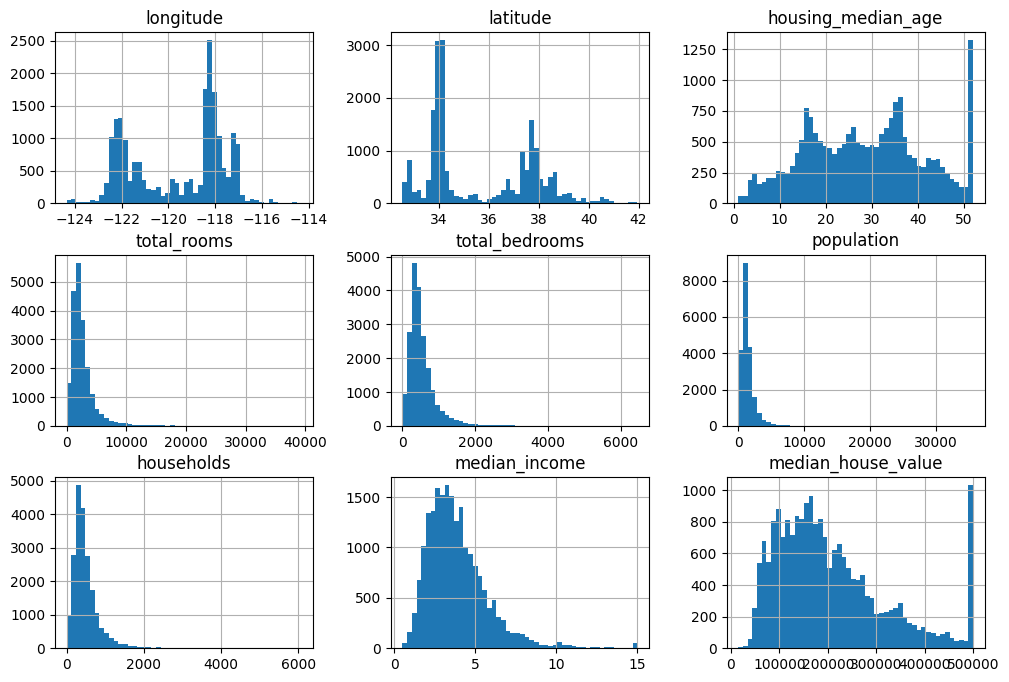

In [102]:
housing_full.hist(bins = 50, figsize=(12,8))

In [103]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [105]:
housing_full.reset_index(inplace=True)
housing_full["index"]

0            0
1            1
2            2
3            3
4            4
         ...  
20635    20635
20636    20636
20637    20637
20638    20638
20639    20639
Name: index, Length: 20640, dtype: int64

In [106]:
from zlib import crc32
# import numpy as np

def is_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_has(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_ : is_in_test_set(id_, test_ratio))
    return data[~in_test_set], data[in_test_set]


In [107]:
train_set, test_set = split_data_with_id_has(housing_full, 0.2, "index")

In [108]:
len(train_set)
len(test_set)

4128

In [110]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"], bins = [0, 1.5, 3, 4.5, 6, np.inf], labels = [1,2,3,4,5])

<Axes: xlabel='income_cat'>

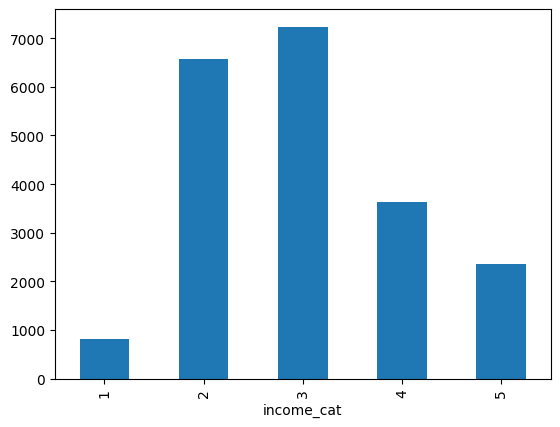

In [111]:
housing_full["income_cat"].value_counts().sort_index().plot.bar()

In [112]:
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split

strat_train_set, start_test_set, = train_test_split(housing_full, test_size=0.2, stratify=housing_full["income_cat"], random_state=42)

In [113]:
strat_train_set["income_cat"].value_counts() / len(strat_train_set)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [114]:
start_test_set["income_cat"].value_counts() / len(start_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [115]:
housing = strat_train_set.copy()

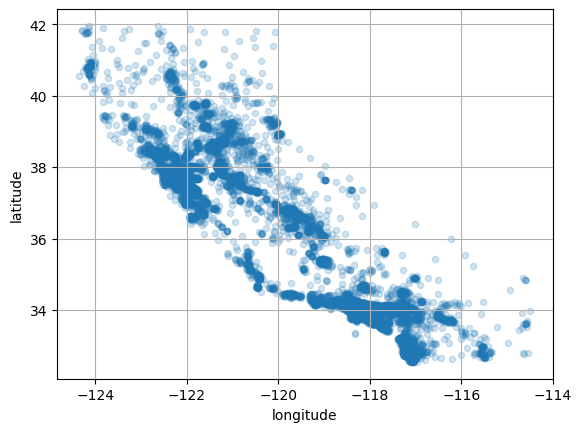

In [116]:
import matplotlib.pyplot as plt
housing.plot(kind = "scatter", x = "longitude", y = "latitude", grid = True, alpha = 0.2)
plt.show()

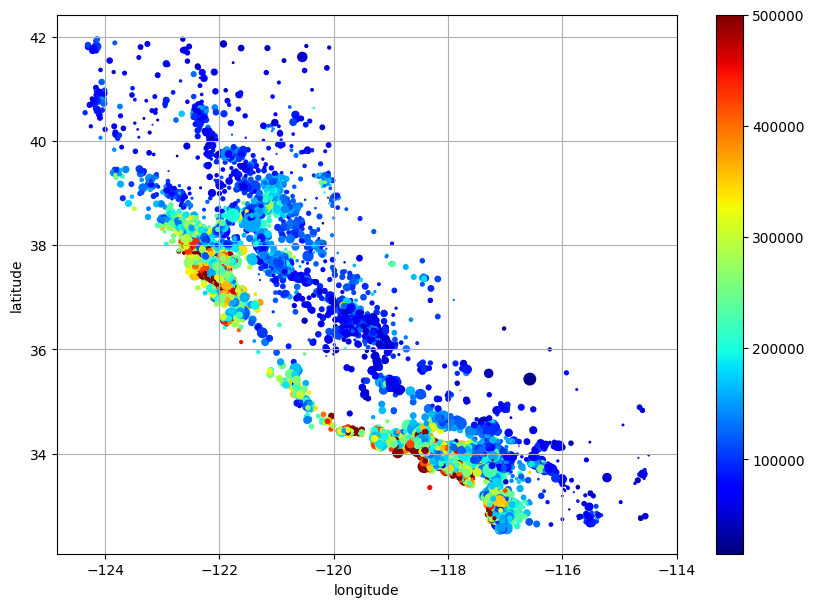

In [117]:
housing.plot(kind = "scatter", x = "longitude", y = "latitude", grid = True, s = housing["population"] / 100, c = housing["median_house_value"], cmap = "jet", colorbar = True, legend = True, sharex = False, figsize = (10, 7))
plt.show()

In [118]:
corr_matrix = housing.corr(numeric_only= True)


In [119]:
corr_matrix["median_house_value"].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
index                -0.008913
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

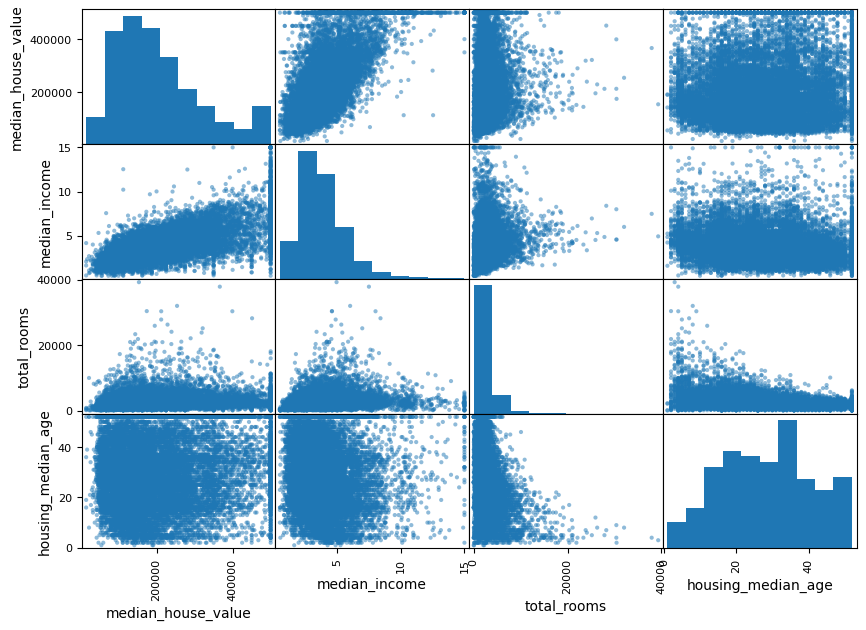

In [120]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(10,7))
plt.show()

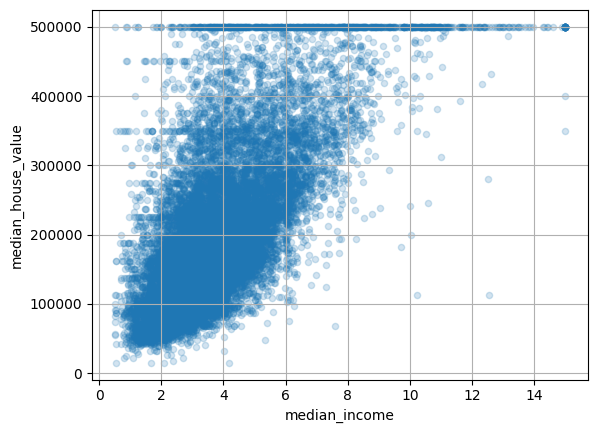

In [121]:
housing.plot(kind = "scatter", x = "median_income", y = "median_house_value", alpha = 0.2, grid = True)
plt.show()

In [ ]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_per_house"] = housing["total_bedrooms"] / housing["households"]
